### Interpet Results

In [1]:
# Run this script to add the src directory to the python path

from notebook_utils import modify_sys_path, get_src_dir_path

modify_sys_path()

In [7]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import re
from csaps import csaps
import scienceplots


from src.utils import calculate_min_Va_by_KL_threshold, calculate_min_Va_by_KL_rank, calculate_mean_Va_by_KL_rank



In [3]:
plt.style.use(['science','no-latex', 'retro', 'grid'])

# Set font size for title
mpl.rcParams['axes.titlesize'] = 26
# Set font size for labels
mpl.rcParams['axes.labelsize'] = 26
# Set font size for tick labels
mpl.rcParams['xtick.labelsize'] = 26
mpl.rcParams['ytick.labelsize'] = 26
mpl.rcParams['legend.fontsize'] = 16

In [29]:
results_directory = "results/logistic_regression_3/llama8b/experiment_5/"

fig_save_directory = "figures/logistic_regression/llama8b/"

seed_list = list(range(0, 10))
shot_list = list(range(5,100,10))

In [30]:
print(shot_list)

[5, 15, 25, 35, 45, 55, 65, 75, 85, 95]


In [37]:

def get_all_shots_df(results_directory: str, shot_list: list[int], seed: int):

    new_results_directory = results_directory + f"seed_{seed}/"

    D_data_list = []

    shots_df_list = []

    for shots in shot_list:
        df_list = []
        print(f"Processing {shots} shots")
        for filename in os.listdir(get_src_dir_path(new_results_directory)):
            if f"D_{shots}_" in filename:
                D_data = pd.read_csv(get_src_dir_path(new_results_directory) + filename)
                D_data_list.append(D_data)
                
            if f"results_{shots}_shot" in filename:
                save_data = pd.read_csv(get_src_dir_path(new_results_directory) + filename)
                df_list.append(save_data)
                
        feature_column = [col for col in D_data.columns if col != 'label' and col != 'note'][0]
                
        for save_data in df_list:
            save_data = calculate_min_Va_by_KL_rank(save_data, num_valid_Va=5, forward_kl=True, upper_bound_by_total_U=True)
            
        PROB_LABELS = ["0", "1"]

        x_x1_list = []
        total_uncertainty_list = []
        kl_pyx_pyxz_list = []
        kl_pyxz_pyx_list = []
        min_Va_list = []    
        max_Ve_list = []
        z_value_for_min_Va_list = []

        prob_y_xz_list = []
        prob_y_x_list = []
        within_threshold_list = []


        for z_df in df_list:
            try:
                x_x1 = z_df[f'x_{feature_column}'].values[0]
                x_x1_list.append(x_x1)
                total_uncertainty = z_df["H[p(y|x,D)]"].values[0]
                total_uncertainty_list.append(total_uncertainty)
                prob_y_xz = {}
                prob_y_x = {}
                # index where z_value_for_min_Va is True
                min_Va_index = z_df[z_df["z_value_for_min_Va"]].index[0]
                z_value_for_min_Va_list.append(z_df[f"z_{feature_column}"].values[min_Va_index])
                for label in PROB_LABELS:
                    prob_y_xz[label] = z_df[f"p(y={label}|x,z,D)"].values[min_Va_index]
                    prob_y_x[label] = z_df[f"p(y={label}|x,D)"].values[min_Va_index]
                prob_y_xz_list.append(prob_y_xz)
                prob_y_x_list.append(prob_y_x)
                kl_pyx_pyxz = z_df["kl_pyx_pyxz"].values[min_Va_index]
                kl_pyx_pyxz_list.append(kl_pyx_pyxz)
                kl_pyxz_pyx = z_df["kl_pyxz_pyx"].values[min_Va_index]
                kl_pyxz_pyx_list.append(kl_pyxz_pyx)
                min_Va = z_df["min_Va"].values[0]
                min_Va_list.append(min_Va)
                max_Ve = z_df["max_Ve"].values[0]
                max_Ve_list.append(max_Ve)
                
                within_threshold_list.append(z_df[z_df["within_threshold"]][f"z_{feature_column}"].values)
                
            except:
                pass
            
        # Create a dataframe from the lists
        data = {f'x_{feature_column}': x_x1_list,
                'total_uncertainty': total_uncertainty_list,
                'min_Va': min_Va_list,
                'max_Ve': max_Ve_list,
                'kl_pyx_pyxz': kl_pyx_pyxz_list,
                'kl_pyxz_pyx': kl_pyxz_pyx_list,
                'z_value_for_min_Va': z_value_for_min_Va_list,
                'within_threshold': within_threshold_list
                }

        for label in PROB_LABELS:
            data[f"p(y={label}|x,z,D)"] = [d[label] for d in prob_y_xz_list]
            data[f"p(y={label}|x,D)"] = [d[label] for d in prob_y_x_list]

        num_Va = len(min_Va_list)

        # reduce the length of list to the number of num_Va
        for key in data.keys():
            data[key] = data[key][:num_Va]

        shots_df = pd.DataFrame(data)

        shots_df = shots_df.sort_values(by='x_x1')
        
        shots_df["shot"] = shots
        
        shots_df_list.append(shots_df)

    all_shots_df = pd.concat(shots_df_list, ignore_index=True)
    
    return all_shots_df, feature_column

def get_all_mean_shots_df(results_directory: str, shot_list: list[int], seed: int):

    new_results_directory = results_directory + f"seed_{seed}/"

    D_data_list = []

    shots_df_list = []

    for shots in shot_list:
        df_list = []
        print(f"Processing {shots} shots")
        for filename in os.listdir(get_src_dir_path(new_results_directory)):
            if f"D_{shots}_" in filename:
                D_data = pd.read_csv(get_src_dir_path(new_results_directory) + filename)
                D_data_list.append(D_data)
                
            if f"results_{shots}_shot" in filename:
                save_data = pd.read_csv(get_src_dir_path(new_results_directory) + filename)
                df_list.append(save_data)
                
        feature_column = [col for col in D_data.columns if col != 'label' and col != 'note'][0]
                
        for save_data in df_list:
            save_data = calculate_mean_Va_by_KL_rank(save_data, num_valid_Va=5, forward_kl=True, upper_bound_by_total_U=True)
            
        PROB_LABELS = ["0", "1"]

        x_x1_list = []
        total_uncertainty_list = []
        min_Va_list = []    
        max_Ve_list = []

        within_threshold_list = []


        for z_df in df_list:
            try:
                x_x1 = z_df[f'x_{feature_column}'].values[0]
                x_x1_list.append(x_x1)
                total_uncertainty = z_df["H[p(y|x,D)]"].values[0]
                total_uncertainty_list.append(total_uncertainty)
                min_Va = z_df["min_Va"].values[0]
                min_Va_list.append(min_Va)
                max_Ve = z_df["max_Ve"].values[0]
                max_Ve_list.append(max_Ve)
                
                within_threshold_list.append(z_df[z_df["within_threshold"]][f"z_{feature_column}"].values)
                
            except:
                pass
            
        # Create a dataframe from the lists
        data = {f'x_{feature_column}': x_x1_list,
                'total_uncertainty': total_uncertainty_list,
                'min_Va': min_Va_list,
                'max_Ve': max_Ve_list,
                'within_threshold': within_threshold_list
                }

        num_Va = len(min_Va_list)

        # reduce the length of list to the number of num_Va
        for key in data.keys():
            data[key] = data[key][:num_Va]

        shots_df = pd.DataFrame(data)

        shots_df = shots_df.sort_values(by='x_x1')
        
        shots_df["shot"] = shots
        
        shots_df_list.append(shots_df)

    all_shots_df = pd.concat(shots_df_list, ignore_index=True)
    
    return all_shots_df, feature_column


In [40]:
all_shots_df_list = []

for seed in seed_list:
    all_shots_df, feature_column = get_all_mean_shots_df(results_directory, shot_list, seed=seed)
    
    all_shots_df["seed"] = seed
    all_shots_df_list.append(all_shots_df)

combined_df = pd.concat(all_shots_df_list, ignore_index=True)

combined_df_group = combined_df.groupby(['x_x1', 'shot'])[['max_Ve', 'min_Va', 'total_uncertainty']].mean().reset_index()

Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots
Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots
Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots
Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots
Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots
Proce

Processing 5 shots
Processing 15 shots
Processing 25 shots
Processing 35 shots
Processing 45 shots
Processing 55 shots
Processing 65 shots
Processing 75 shots
Processing 85 shots
Processing 95 shots


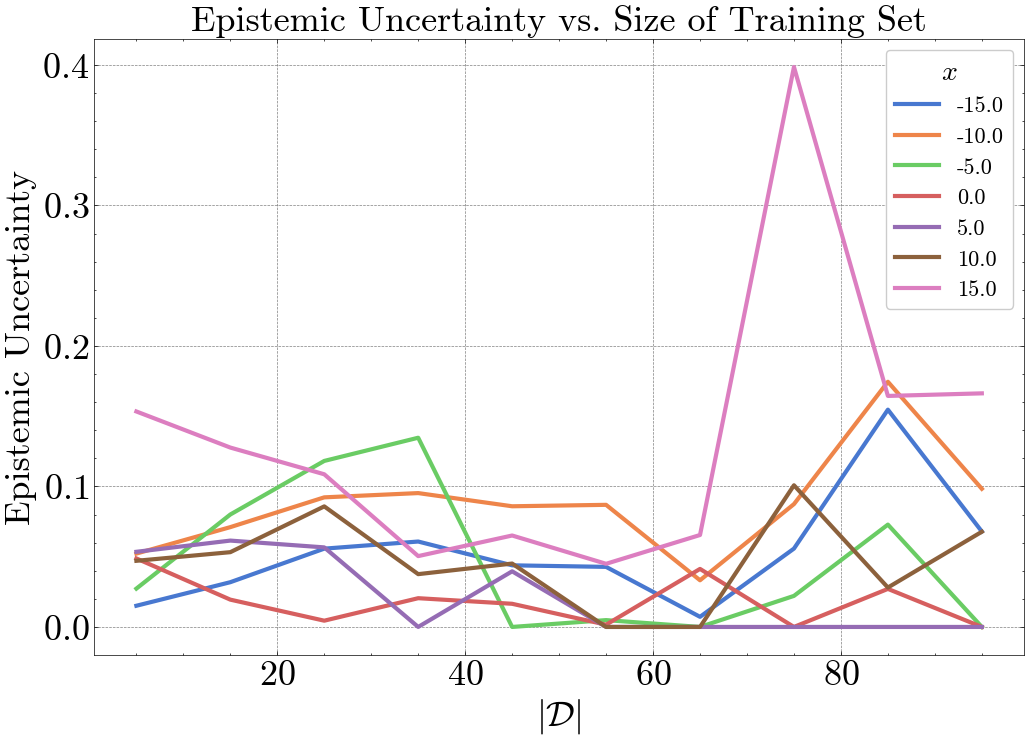

In [39]:
all_shots_df, feature_column = get_all_mean_shots_df(results_directory, shot_list, seed=0)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot shots against min_Va for each x_{feature_column}

sns.lineplot(data=all_shots_df, x="shot", y="max_Ve", hue = f"x_{feature_column}", palette="muted", linewidth=3)
legend = ax.legend(title=r"$x$", loc='upper right', title_fontsize=20)
plt.xlabel(r"$|\mathcal{D}|$")
plt.ylabel("Epistemic Uncertainty")
plt.title(r"Epistemic Uncertainty vs. Size of Training Set")
plt.show()

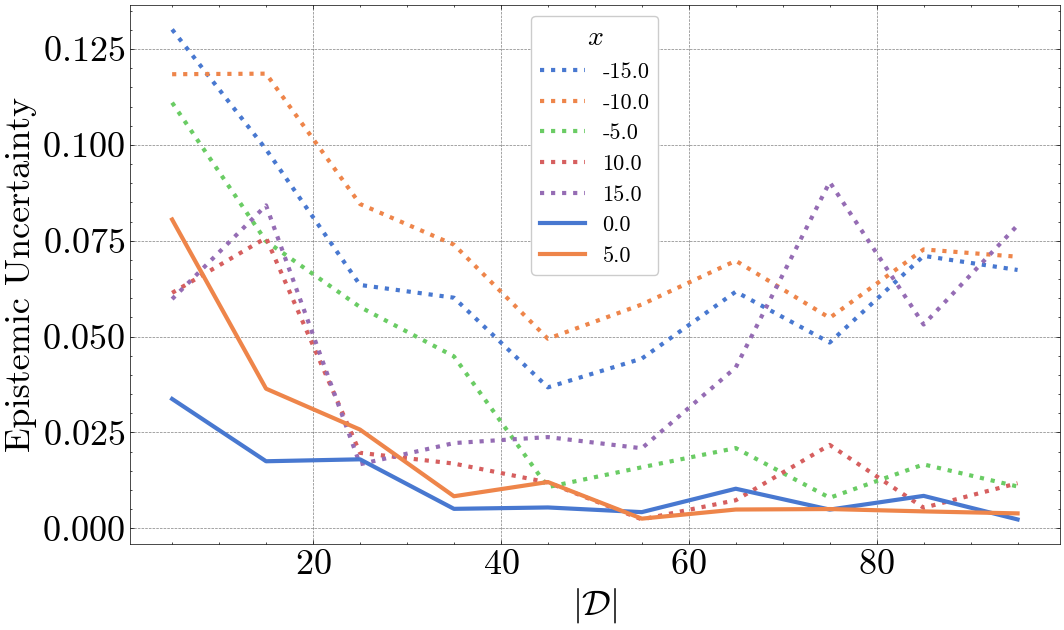

In [42]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot shots against min_Va for each x_{feature_column}

for key, group in combined_df_group.groupby(combined_df_group[f"x_{feature_column}"].isin([0, 5])):
    linestyle = '-' if key else ':' 
    sns.lineplot(data=group, x="shot", y="max_Ve", hue = f"x_{feature_column}", linestyle=linestyle, palette="muted", linewidth=3)
legend = ax.legend(title=r"$x$", title_fontsize=20)
plt.xlabel(r"$|\mathcal{D}|$")
plt.ylabel("Epistemic Uncertainty")
# plt.title(r"Epistemic Uncertainty vs. Size of Training Set")
# plt.savefig(fig_save_directory + "epistemic_uncertainty_vs_shots.pdf", dpi=300, bbox_inches='tight')
plt.show()

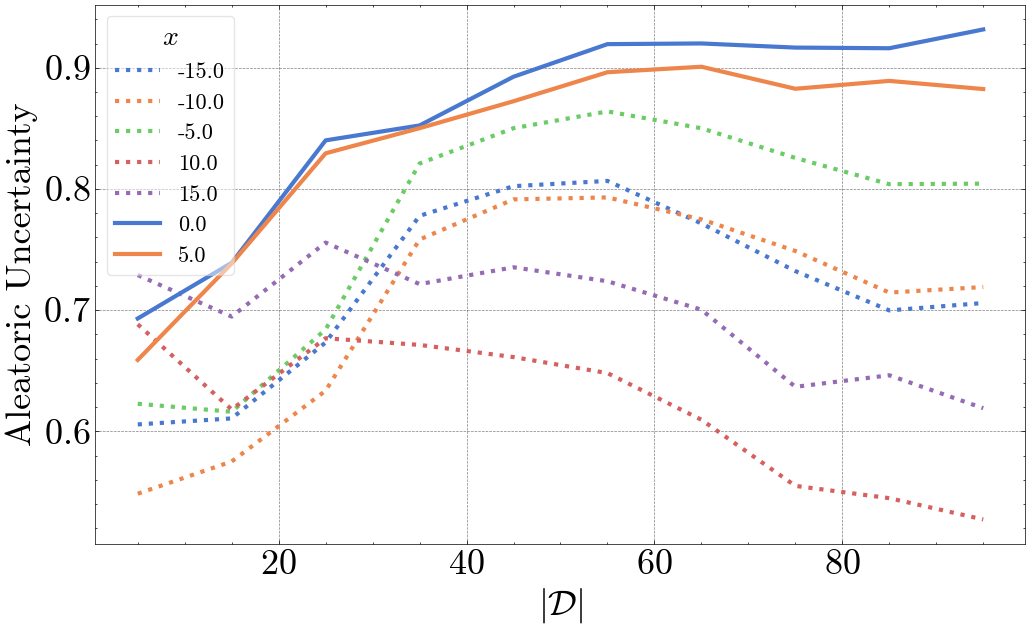

In [35]:
fig, ax = plt.subplots(figsize=(12, 7))

# Plot shots against min_Va for each x_{feature_column}

for key, group in combined_df_group.groupby(combined_df_group[f"x_{feature_column}"].isin([0, 5])):
    linestyle = '-' if key else ':' 
    sns.lineplot(data=group, x="shot", y="min_Va", hue = f"x_{feature_column}", palette="muted", linestyle=linestyle, linewidth=3)
legend = ax.legend(title=r"$x$", title_fontsize=20, framealpha=0.5)
plt.xlabel(r"$|\mathcal{D}|$")
plt.ylabel("Aleatoric Uncertainty")
# plt.title(r"Aleatoric Uncertainty vs. Size of Training Set")
# plt.savefig(fig_save_directory + "aleatoric_uncertainty_vs_shots.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [42]:

x_x1_array = np.array(all_shots_df[f"x_{feature_column}"].unique())

probs = 1/(1+np.exp(-(x_x1_array * 0.25 - 0.5)))

entropies = - probs * np.log2(probs) - (1 - probs) * np.log2(1 - probs)

In [43]:
print(x_x1_array)
print(entropies)

[-15. -10.  -5.   0.   5.  10.  15.]
[0.10666403 0.27535995 0.60493176 0.95628654 0.90527236 0.52706534
 0.22989887]
